In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv("fm_data.csv")
df.head()

,Unnamed: 0,Username,Artist,Track,Album,Date,Time
0,0,Babs_05,Isobel Campbell,The Circus Is Leaving Town,Ballad of the Broken Seas,31 Jan 2021,23:36
1,1,Babs_05,Isobel Campbell,Dusty Wreath,Ballad of the Broken Seas,31 Jan 2021,23:32
2,2,Babs_05,Isobel Campbell,Honey Child What Can I Do?,Ballad of the Broken Seas,31 Jan 2021,23:28
3,3,Babs_05,Isobel Campbell,It's Hard To Kill A Bad Thing,Ballad of the Broken Seas,31 Jan 2021,23:25
4,4,Babs_05,Isobel Campbell,Saturday's Gone,Ballad of the Broken Seas,31 Jan 2021,23:21


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 166153 entries, 0 to 166152
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  166153 non-null  int64
 1   Username    166153 non-null  str  
 2   Artist      166153 non-null  str  
 3   Track       166153 non-null  str  
 4   Album       166141 non-null  str  
 5   Date        166153 non-null  str  
 6   Time        166153 non-null  str  
dtypes: int64(1), str(6)
memory usage: 8.9 MB


In [ ]:
df['Datetime'] = pd.to_datetime(df['Date'].str.strip() + df['Time'], format='%d %b %Y %H:%M')
df['ContinuousDay'] = df['Datetime'].dt.dayofyear + (df['Datetime'].dt.hour + df['Datetime'].dt.minute / 60) / 24
df[['Username', 'Datetime', 'ContinuousDay']].head(10)

,Username,Datetime,ContinuousDay
0,Babs_05,2021-01-31 23:36:00,31.983333
1,Babs_05,2021-01-31 23:32:00,31.980556
2,Babs_05,2021-01-31 23:28:00,31.977778
3,Babs_05,2021-01-31 23:25:00,31.975694
4,Babs_05,2021-01-31 23:21:00,31.972917
5,Babs_05,2021-01-31 23:17:00,31.970139
6,Babs_05,2021-01-31 23:14:00,31.968056
7,Babs_05,2021-01-31 23:11:00,31.965972
8,Babs_05,2021-01-31 23:08:00,31.963889
9,Babs_05,2021-01-31 23:04:00,31.961111


In [13]:
# Get day of year for each row
df['DayOfYear'] = df['Datetime'].dt.dayofyear

# Count songs per user per day
daily_counts = df.groupby(['Username', 'DayOfYear']).size().reset_index(name='SongCount')

# Pivot: rows = DayOfYear, columns = Username, values = SongCount
daily_counts_pivot = daily_counts.pivot(index='DayOfYear', columns='Username', values='SongCount')
daily_counts_pivot = daily_counts_pivot.fillna(0).astype(int)

daily_counts_pivot

Username,Babs_05,Knapster01,Orlenay,eartle,franhale,isaac,jajo,jonocole,lobsterclaw,massdosage,mremond
DayOfYear,,,,,,,,,,,
1,52,49,29,53,61,23,0,27,0,43,0
2,45,21,73,29,89,1,0,9,0,37,0
3,52,50,31,32,19,0,0,77,0,37,0
4,33,0,19,19,4,0,0,19,0,13,0
5,42,66,26,81,39,2,0,42,0,11,0
6,36,101,60,74,25,21,21,50,21,49,21
7,39,16,6,62,86,1,0,35,0,77,0
8,40,80,2,112,87,0,0,131,0,75,0
9,94,52,50,58,48,1,0,47,0,33,0


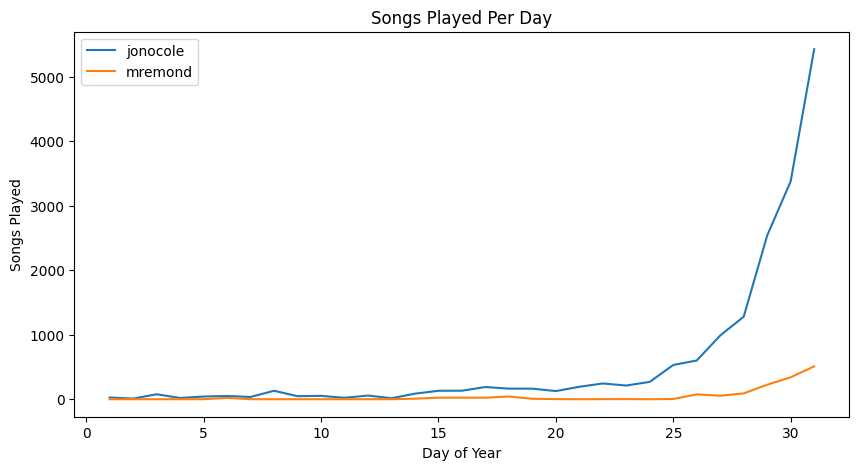

In [14]:
# Plot song count per day for two random users
users = daily_counts_pivot.columns.to_list()
two_users = np.random.choice(users, size=2, replace=False)

plt.figure(figsize=(10, 5))
plt.plot(daily_counts_pivot.index, daily_counts_pivot[two_users[0]], label=two_users[0])
plt.plot(daily_counts_pivot.index, daily_counts_pivot[two_users[1]], label=two_users[1])
plt.xlabel('Day of Year')
plt.ylabel('Songs Played')
plt.title('Songs Played Per Day')
plt.legend()
plt.show()

In [ ]:
play_df = (
    df[['Username', 'ContinuousDay']]
    .sort_values(['Username', 'ContinuousDay'])
    .reset_index(drop=True)
)

print(f"Shape: {play_df.shape}")
print(f"Users: {play_df['Username'].nunique()}")
play_df.head(10)

Shape: (166153, 2)
Users: 11


,Username,ContinuousDay
0,Babs_05,1.001389
1,Babs_05,1.006250
2,Babs_05,1.009722
3,Babs_05,1.013194
4,Babs_05,1.015972
5,Babs_05,1.019444
6,Babs_05,1.022222
7,Babs_05,1.022917
8,Babs_05,1.025000
9,Babs_05,1.027083


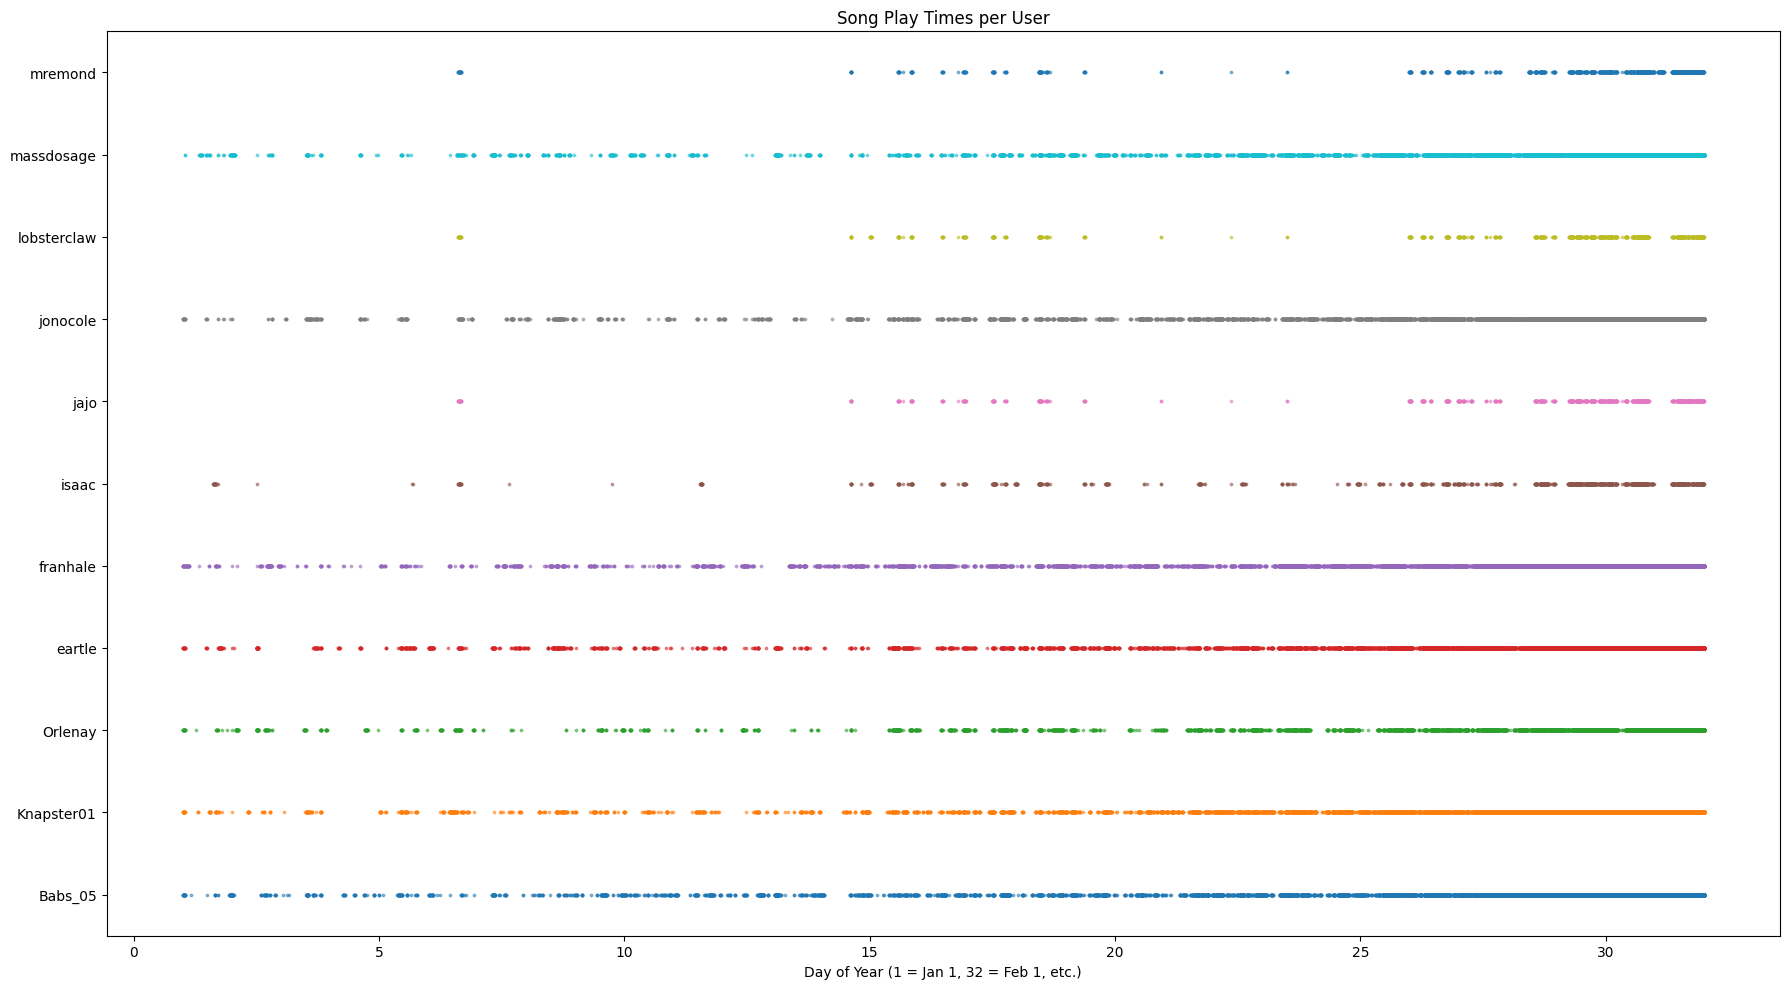

In [11]:
# Plot: each user's song plays over continuous time
fig, ax = plt.subplots(figsize=(18, 10))

users = play_df['Username'].unique()
for i, user in enumerate(users):
    user_data = play_df[play_df['Username'] == user]
    ax.scatter(user_data['ContinuousDay'], [i] * len(user_data), label=user, s=3, alpha=0.5)

ax.set_yticks(range(len(users)))
ax.set_yticklabels(users)
ax.set_xlabel('Day of Year (1 = Jan 1, 32 = Feb 1, etc.)')
ax.set_title('Song Play Times per User')
plt.tight_layout()
plt.show()